# **Import libraries**

In [ ]:
import tensorflow
import tensorflow_datasets as tfds
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix # this creates a confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay # draws a confusion matrix
from scipy.stats import uniform
from scipy.stats import loguniform
import joblib
import matplotlib.pyplot as plt

# **Loading the dataset**


Load dataset from `tensorflow_datasets`. Use the built-in `split` parameter to split the dataset into training and test sets. Hurray for less manual work!

In [ ]:
ds, info = tfds.load("imdb_reviews", split=["train", "test"], with_info=True, as_supervised=True)
train_ds, test_ds = ds

Converting to dataframes

In [ ]:
# Convert TFDS to pandas DataFrame
def to_dataframe(tfds_split):
    texts, labels = [], []
    for text, label in tfds.as_numpy(tfds_split):
        texts.append(text.decode("utf-8"))  # convert from bytes to string
        labels.append(int(label))
    return pd.DataFrame({"review": texts, "sentiment": labels})

df_train = to_dataframe(train_ds)
df_test = to_dataframe(test_ds)
# 0 = negative;;;;; 1 = positive

In [ ]:
print(df_train)

                                                  review  sentiment
0      This was an absolutely terrible movie. Don't b...          0
1      I have been known to fall asleep during films,...          0
2      Mann photographs the Alberta Rocky Mountains i...          0
3      This is the kind of film for a snowy Sunday af...          1
4      As others have mentioned, all the women that g...          1
...                                                  ...        ...
24995  I have a severe problem with this show, severa...          0
24996  The year is 1964. Ernesto "Che" Guevara, havin...          1
24997  Okay. So I just got back. Before I start my re...          0
24998  When I saw this trailer on TV I was surprised....          0
24999  First of all, Riget is wonderful. Good comedy ...          1

[25000 rows x 2 columns]


Splitting into features and label

In [ ]:
X_train = df_train['review']
y_train = df_train['sentiment']
X_test = df_test['review']
y_test = df_test['sentiment']

# **Pre-Processing**

Vectorization TF-IDF / Feature Engineering

In [ ]:
# --- TF-IDF Vectorization Code ---
print("--- Starting TF-IDF Vectorization ---")
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),   # unigrams + bigrams
    min_df=2             # ignore words that appear only once
)
# X_train_tfidf = vectorizer.fit_transform(X_train_preprocessed)
# X_test_tfidf = vectorizer.transform(X_test_preprocessed)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Shape of X_train_tfidf:", X_train_tfidf.shape)
print("Shape of X_test_tfidf:", X_test_tfidf.shape)

--- Starting TF-IDF Vectorization ---
Shape of X_train_tfidf: (25000, 10000)
Shape of X_test_tfidf: (25000, 10000)


# **Modeling Phase**


## **Wayne**

Multinomial Naives Bayes



---



### Train model with optimal `alpha` parameter

In [ ]:
params = {
    'alpha': uniform(loc=0.01, scale=1.0) # Search a range of alpha values
}

random_search = RandomizedSearchCV(
    MultinomialNB(),
    params,
    n_iter=50, # Number of different parameter settings to try
    cv=5, # Using 5-fold cross-validation
    scoring='accuracy', # Accuracy is valid scoring because this dataset is perfectly balanced, the model cannot increase accuracy just by predicting majority class
    n_jobs=-1,
    random_state=69
)

print("Starting Randomized Search on Multinomial Naive Bayes...")
random_search.fit(X_train_tfidf, y_train)
print("Random Search Completed")

Starting Randomized Search on Multinomial Naive Bayes...
Random Search Completed


In [ ]:
# LOGGING THE BEST PARAMETER AND ALSO BEST MODEL
print("\nBest Parameters:", random_search.best_params_)
best_mnb = random_search.best_estimator_


Best Parameters: {'alpha': np.float64(0.04198771223661634)}


### Evaluate the model on different metrics

In [ ]:
# TESTING THE MODEL

y_pred = best_mnb.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1 Score: {f1}")

# Detailed per-class report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.86332
Precision: 0.8633360193397583
Recall: 0.86332
F1 Score: 0.8633184934417621

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86     12500
           1       0.86      0.87      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



### Confusion matrix

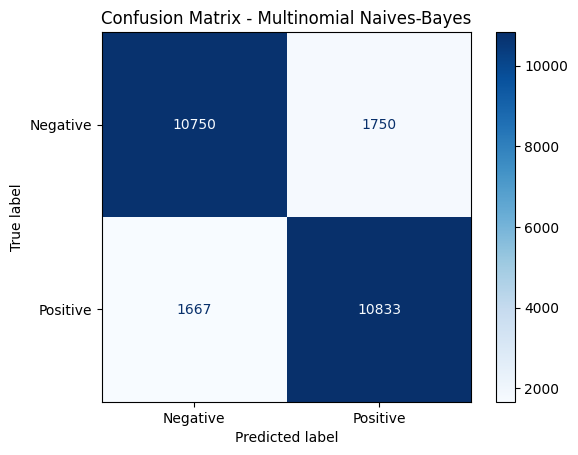

In [ ]:
# Confusion Matrix for Multinomial Naives-Bayes
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Multinomial Naives-Bayes")
plt.show()

### Create a pipeline

In [ ]:
'''
Inserting everything into a pipeline and dumping it incase this model is the one with the highest performance.
'''
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=2)),
    ('classifier', MultinomialNB(alpha=random_search.best_params_['alpha'])),
])

print("Fitting....")
pipe.fit(X_train, y_train)
print("Fitting Completed")
joblib.dump(pipe, 'sentiment_analysis_pipeline.joblib')

Fitting....
Fitting Completed


['sentiment_analysis_pipeline.joblib']

### Test the pipeline

In [ ]:
test_reviews = [
    # Negative
    "The plot was boring and predictable.",
    "I really did not enjoy this movie at all.",
    "The acting was terrible, no chemistry between the cast.",
    "I can't believe I wasted two hours on this.",

    # Positive
    "Absolutely loved it, the story was touching and well-paced.",
    "Great performances and beautiful cinematography.",
    "This film was amazing, one of the best I've seen in years.",
    "I enjoyed every single moment of it!",

    # Tricky / Mixed
    "The movie was good, but not great.",
    "It’s not bad, actually pretty decent.",
    "Never boring, always kept me interested.",
    "The story was okay, but not the acting.",

    # Sarcastic / Ambiguous
    "Yeah, this was the greatest movie ever... not!",
    "Well, at least the popcorn was good.",
    "I expected better, but it could’ve been worse."
]
for review in test_reviews:
  pred = pipe.predict([review])  # <-- raw text!
  print(review)
  print("Prediction:", "Negative" if pred[0] == 0 else "Positive")
  print()

The plot was boring and predictable.
Prediction: Negative

I really did not enjoy this movie at all.
Prediction: Negative

The acting was terrible, no chemistry between the cast.
Prediction: Negative

I can't believe I wasted two hours on this.
Prediction: Negative

Absolutely loved it, the story was touching and well-paced.
Prediction: Positive

Great performances and beautiful cinematography.
Prediction: Positive

This film was amazing, one of the best I've seen in years.
Prediction: Positive

I enjoyed every single moment of it!
Prediction: Positive

The movie was good, but not great.
Prediction: Negative

It’s not bad, actually pretty decent.
Prediction: Negative

Never boring, always kept me interested.
Prediction: Negative

The story was okay, but not the acting.
Prediction: Negative

Yeah, this was the greatest movie ever... not!
Prediction: Negative

Well, at least the popcorn was good.
Prediction: Negative

I expected better, but it could’ve been worse.
Prediction: Negative




## **Song Lynn**
Logistic Regression

---

### Train and evaluate the model, and create a pipeline

In [ ]:
# Create simple Logistic Regression model with default parameters
lr_model = LogisticRegression(random_state=69, n_jobs=-1)

print("Training Logistic Regression...")
lr_model.fit(X_train_tfidf, y_train)
print("Logistic Regression Training Completed")

# Evaluate on test set
lr_y_pred = lr_model.predict(X_test_tfidf)
lr_accuracy = (lr_y_pred == y_test).mean()
print(f"Logistic Regression Accuracy: {lr_accuracy:.5f}")

precision = precision_score(y_test, lr_y_pred, average="weighted")
recall = recall_score(y_test, lr_y_pred, average="weighted")
f1 = f1_score(y_test, lr_y_pred, average="weighted")

print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# Detailed per-class report
print("\nClassification Report:")
print(classification_report(y_test, lr_y_pred))

# Create simple Logistic Regression Pipeline
lr_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=2)),
    ('classifier', LogisticRegression(random_state=69, n_jobs=-1))
])

lr_pipe.fit(X_train, y_train)
final_pipeline = lr_pipe
joblib.dump(lr_pipe, 'logistic_regression_pipeline.joblib')
print("Logistic Regression Pipeline saved as 'logistic_regression_pipeline.joblib'")

# Quick validation
print("\nQuick validation of final pipeline:")
final_predictions = final_pipeline.predict(X_train[:100])  # Test on first 100 samples
print(f"Sample predictions shape: {final_predictions.shape}")


Training Logistic Regression...
Logistic Regression Training Completed
Logistic Regression Accuracy: 0.89248
Precision: 0.89253
Recall:    0.89248
F1 Score:  0.89248

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.89     12500
           1       0.89      0.90      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000

Logistic Regression Pipeline saved as 'logistic_regression_pipeline.joblib'

Quick validation of final pipeline:
Sample predictions shape: (100,)


### Confusion matrix

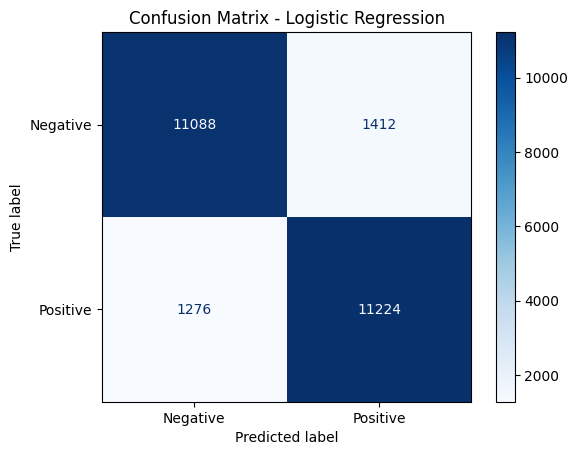

In [ ]:
# Confusion Matrix for Logistic Regression model
cm = confusion_matrix(y_test, lr_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
display_labels=["Negative", "Positive"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()



### Test the pipeline

In [ ]:
test_reviews = [
    # Negative
    "The plot was boring and predictable.",
    "I really did not enjoy this movie at all.",
    "The acting was terrible, no chemistry between the cast.",
    "I can't believe I wasted two hours on this.",

    # Positive
    "Absolutely loved it, the story was touching and well-paced.",
    "Great performances and beautiful cinematography.",
    "This film was amazing, one of the best I've seen in years.",
    "I enjoyed every single moment of it!",

    # Tricky / Mixed
    "The movie was good, but not great.",
    "It’s not bad, actually pretty decent.",
    "Never boring, always kept me interested.",
    "The story was okay, but not the acting.",

    # Sarcastic / Ambiguous
    "Yeah, this was the greatest movie ever... not!",
    "Well, at least the popcorn was good.",
    "I expected better, but it could’ve been worse."
]
for review in test_reviews:
  pred = lr_pipe.predict([review])  # <-- raw text!
  print(review)
  print("Prediction:", "Negative" if pred[0] == 0 else "Positive")
  print()

The plot was boring and predictable.
Prediction: Negative

I really did not enjoy this movie at all.
Prediction: Negative

The acting was terrible, no chemistry between the cast.
Prediction: Negative

I can't believe I wasted two hours on this.
Prediction: Negative

Absolutely loved it, the story was touching and well-paced.
Prediction: Positive

Great performances and beautiful cinematography.
Prediction: Positive

This film was amazing, one of the best I've seen in years.
Prediction: Positive

I enjoyed every single moment of it!
Prediction: Positive

The movie was good, but not great.
Prediction: Positive

It’s not bad, actually pretty decent.
Prediction: Negative

Never boring, always kept me interested.
Prediction: Negative

The story was okay, but not the acting.
Prediction: Negative

Yeah, this was the greatest movie ever... not!
Prediction: Positive

Well, at least the popcorn was good.
Prediction: Positive

I expected better, but it could’ve been worse.
Prediction: Negative




## **Le Herng**
**Support Vector Machine (SVM)**

---

### Train model with optimal `C` parameter

Since our dataset is large, I'm going to use **linear kernel** for my SVM. The key parameter that we need to tune for a linear SVM is `C`, the regularization parameter. In very simple terms, high `C` gives a smoother, more generalized decision boundary (high bias, low variance), and low `C` gives a more wiggly, tightly-fit decision boundary (low bias, high variance).

We can look for the best C value by running a **randomized search** over a range from **0.001** to **1000**, but instead of treating the range as linear, we use a **logarithmic** scale. In practice, this means values like 0.001, 0.01, 10, and 1000 are all just as likely to be picked during the search.

In [ ]:
# Find optimal C (regularization) parameter

params = {
    "C": loguniform(1e-3, 1e3)  # samples values logarithmically between 0.001 and 1000
}

random_search = RandomizedSearchCV(
    LinearSVC(), # more efficient than SVC(kernel='linear')
    params,
    n_iter=50, # Number of different parameter settings to try
    cv=5, # Using 5-fold cross-validation
    scoring='accuracy', # Accuracy is valid scoring because this dataset is perfectly balanced, the model cannot increase accuracy just by predicting majority class
    n_jobs=-1,
    random_state=42 # random seed
)

print("Starting Randomized Search on Linear SVM...")
random_search.fit(X_train_tfidf, y_train)
print("Random Search Completed")

print("\nBest Parameters:", random_search.best_params_)

Starting Randomized Search on Linear SVM...
Random Search Completed

Best Parameters: {'C': np.float64(0.4374364439939078)}


### Evaluate the model on different metrics

Let's **test** the model out on our test data, and **evaluate** the model using metrics like Accuracy, Precision, Recall, and F1 Score.

In [ ]:
best_lin_svm = random_search.best_estimator_
y_pred = best_lin_svm.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1 Score: {f1}")

# Detailed per-class report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.89404
Precision: 0.8940657271326878
Recall: 0.89404
F1 Score: 0.8940382705350364

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.89     12500
           1       0.89      0.90      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



### Confusion matrix

Draw confusion matrix for linear SVM

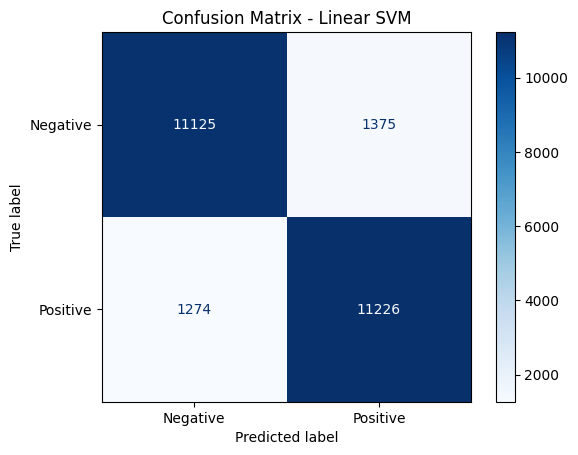

In [ ]:
disp = ConfusionMatrixDisplay.from_estimator(
    best_lin_svm,
    X_test_tfidf,
    y_test,
    display_labels=["Negative", "Positive"],
    cmap="Blues",
    values_format="d"
)
disp.ax_.set_title("Confusion Matrix - Linear SVM")
plt.show()


### Create a pipeline

Now let's put everything into a **pipeline**!

In [ ]:
optimal_C = random_search.best_params_['C']
pipe_svm = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=2)),
    ('classifier', LinearSVC(C=optimal_C)),
])

print("Fitting....")
pipe_svm.fit(X_train, y_train)
print("Fitting Completed")

Fitting....
Fitting Completed


Export the model as a `.joblib` file.

In [ ]:
joblib.dump(pipe_svm, 'linear_svm_pipeline.joblib')

['linear_svm_pipeline.joblib']

Now we can pass in an array of **raw text** into the pipeline, and out will come the predictions! It does the cleaning, vectorizing and predicting all in one go.

In [ ]:
test_reviews = {
    'Negative': [
        "The plot was boring and predictable.",
        "I really did not enjoy this movie at all.",
        "The acting was terrible, no chemistry between the cast.",
        "I can't believe I wasted two hours on this.",
    ],

    'Positive': [
        "Absolutely loved it, the story was touching and well-paced.",
        "Great performances and beautiful cinematography.",
        "This film was amazing, one of the best I've seen in years.",
        "I enjoyed every single moment of it!",
    ],

    'Tricky / Mixed': [
        "The movie was good, but not great.",
        "It’s not bad, actually pretty decent.",
        "Never boring, always kept me interested.",
        "The story was okay, but not the acting.",
    ],

    'Sarcastic / Ambiguous': [
        "Yeah, this was the greatest movie ever... not!",
        "Well, at least the popcorn was good.",
        "I expected better, but it could’ve been worse."
    ],
}

for category, reviews in test_reviews.items():
    print("-------------------")
    print(category, "reviews")
    print("-------------------")
    for review in reviews:
        pred = pipe_svm.predict([review])  # <-- raw text!
        print(review)
        print("Prediction:", "Negative" if pred[0] == 0 else "Positive")
        print()

-------------------
Negative reviews
-------------------
The plot was boring and predictable.
Prediction: Negative

I really did not enjoy this movie at all.
Prediction: Negative

The acting was terrible, no chemistry between the cast.
Prediction: Negative

I can't believe I wasted two hours on this.
Prediction: Negative

-------------------
Positive reviews
-------------------
Absolutely loved it, the story was touching and well-paced.
Prediction: Positive

Great performances and beautiful cinematography.
Prediction: Positive

This film was amazing, one of the best I've seen in years.
Prediction: Positive

I enjoyed every single moment of it!
Prediction: Positive

-------------------
Tricky / Mixed reviews
-------------------
The movie was good, but not great.
Prediction: Positive

It’s not bad, actually pretty decent.
Prediction: Negative

Never boring, always kept me interested.
Prediction: Negative

The story was okay, but not the acting.
Prediction: Negative

-------------------
S

# Comparing the three models

In [ ]:

print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

# Compare model performance
mnb_accuracy = (best_mnb.predict(X_test_tfidf) == y_test).mean()

print(f"Multinomial Naive Bayes Accuracy: {mnb_accuracy:.5f}")
print(f"Logistic Regression Accuracy:     {lr_accuracy:.5f}")
print(f"Linear SVM Accuracy:     {acc:.5f}")

# Determine best model
if lr_accuracy >= mnb_accuracy and lr_accuracy >= acc:
    best_model = lr_model
    best_model_name = "Logistic Regression"
    best_accuracy = lr_accuracy
elif mnb_accuracy >= lr_accuracy and mnb_accuracy >= acc:
    best_model = mnb_model
    best_model_name = "Multinomial Naive Bayes"
    best_accuracy = mnb_accuracy
else:
    best_model = best_lin_svm
    best_model_name = "Linear SVM"
    best_accuracy = acc


print(f"\nBest Model: {best_model_name} with accuracy: {best_accuracy:.5f}")



MODEL COMPARISON
Multinomial Naive Bayes Accuracy: 0.86332
Logistic Regression Accuracy:     0.89248
Linear SVM Accuracy:     0.89404

Best Model: Linear SVM with accuracy: 0.89404
